# Bitcoin Sentiment vs Trader Performance

## Objective
Analyze how market sentiment (Fear/Greed Index) impacts trader profitability and behavior.

## Dataset
- Historical trading data (Hyperliquid)
- Bitcoin Fear & Greed Index

## Goal
- Identify patterns between sentiment and trading performance
- Build a model to predict trade profitability

In [7]:
import sys
import os

sys.path.append(os.path.abspath('../'))
os.chdir('..')

In [8]:
#load data
from src.data_loader import load_all_data
trader_df, sentiment_df = load_all_data()

Trader Data : (211224, 16) 
Sentiment Data : (2644, 4)
Trader Data Preview:                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Timestamp  
0     True  0.345404  8.950000e+14  1.730000e+12  
1     True  0.005600  4.430000e+14  1.730000e+12   
Sentiment Data Preview :     timestamp  value classification        date
0  1

In [9]:
#preprocessing
from src.preprocessing import preprocess_trader_data, preprocess_sentiment_data, merge_data

trader_df = preprocess_trader_data(trader_df)
sentiment_df = preprocess_sentiment_data(sentiment_df)

df = merge_data(trader_df, sentiment_df)

df.head()

Null Timestamp Values: 131999


c:\Projects\btc-sentiment-trader-analysis\src\preprocessing.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trader_df['date'] = trader_df['Timestamp IST'].dt.date
c:\Projects\btc-sentiment-trader-analysis\src\preprocessing.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce')
c:\Projects\btc-sentiment-trader-analysis\src\preprocessing.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

Before Merge - Trader Data: (79225, 17), Sentiment Data: (2644, 4)
After Merge - Merged Data: (79225, 20)
Null Classification Values: 43361
Final Data Shape after cleaning: (35864, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,greed


We clean timestamps, align dates, and merge both datasets on daily sentiment.

In [10]:
#data overview 
print(df.shape)
df.describe()

(35864, 20)


,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
count,35864.000000,3.586400e+04,3.586400e+04,35864,3.586400e+04,35864.000000,3.586400e+04,35864.000000,3.586400e+04,3.586400e+04,3.586400e+04,35864.00000
mean,7596.431745,1.004709e+04,4.920359e+03,2024-11-29 15:03:36.594914560,2.701678e+04,101.070948,5.844251e+10,1.028091,5.619946e+14,1.732824e+12,1.732869e+09,51.33496
min,0.000005,5.630000e-06,0.000000e+00,2023-01-05 01:06:00,-1.050000e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.672897e+09,15.00000
25%,3.245975,2.588700e+00,1.665300e+02,2024-09-12 12:47:00,-2.638983e+02,0.000000,5.240387e+10,0.012518,2.780000e+14,1.730000e+12,1.726119e+09,28.00000
50%,16.390000,2.820000e+01,5.979050e+02,2025-01-05 07:06:00,7.010137e+01,0.000000,6.815193e+10,0.084384,5.620000e+14,1.740000e+12,1.736055e+09,49.00000
75%,172.590000,1.990000e+02,2.220243e+03,2025-03-04 13:18:00,1.090053e+04,10.735428,7.641909e+10,0.398132,8.460000e+14,1.740000e+12,1.741066e+09,72.00000
max,103265.000000,1.582244e+07,1.190250e+06,2025-05-02 23:59:00,3.050948e+07,71535.716740,9.014923e+10,212.298921,1.130000e+15,1.750000e+12,1.746164e+09,90.00000
std,23547.203213,2.060973e+05,2.203314e+04,NaN,4.308246e+05,1364.610762,2.240666e+10,4.937482,3.262737e+14,1.082266e+10,1.134941e+07,22.06305


After preprocessing, the dataset is reduced due to timestamp inconsistencies and missing sentiment matches.

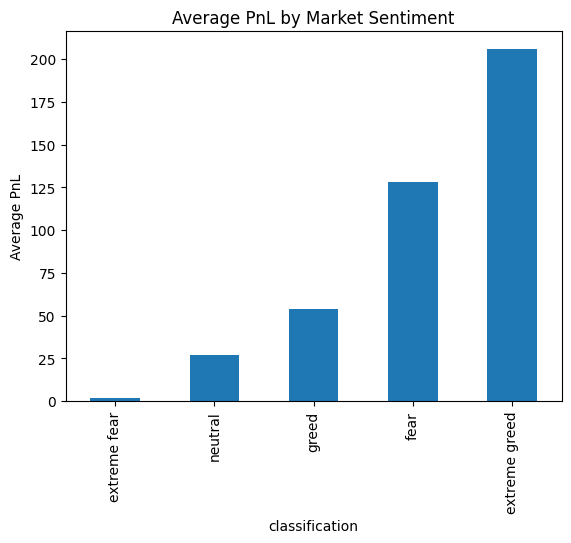

In [11]:
import matplotlib.pyplot as plt

df.groupby('classification')['Closed PnL'].mean().sort_values().plot(
    kind='bar',
    title='Average PnL by Market Sentiment'
)
plt.ylabel("Average PnL")
plt.show()

Profitability increases significantly as sentiment shifts from Fear to Greed.

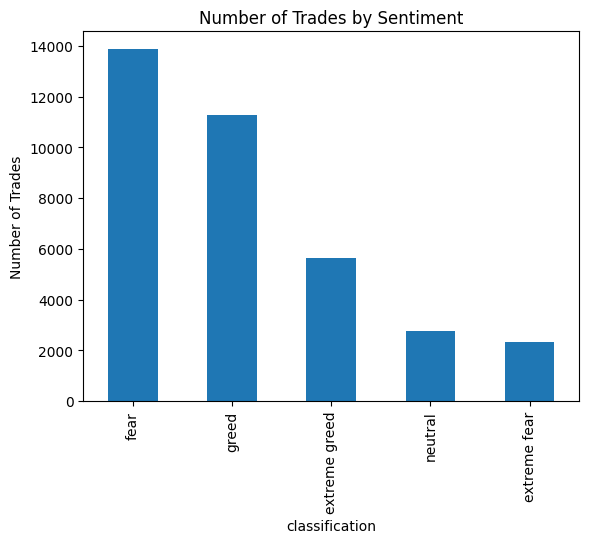

In [12]:
df['classification'].value_counts().plot(
    kind='bar',
    title='Number of Trades by Sentiment'
)
plt.ylabel("Number of Trades")
plt.show()

Most trading activity occurs during Fear and Greed phases, indicating higher market participation during volatility.

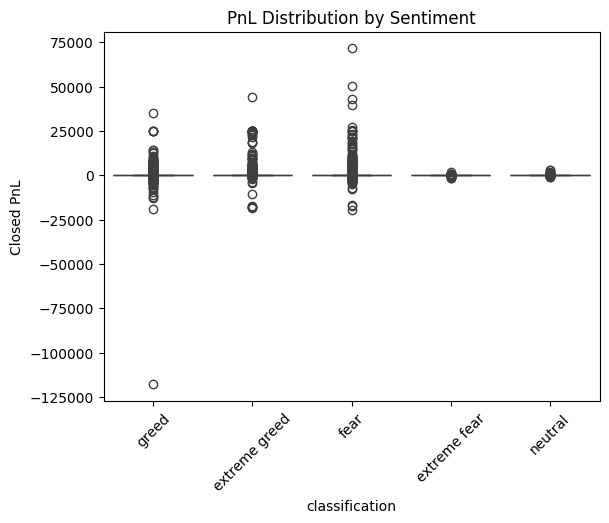

In [13]:
import seaborn as sns

sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.xticks(rotation=45)
plt.title('PnL Distribution by Sentiment')
plt.show()

Extreme sentiment conditions show higher variability in returns, indicating increased risk.

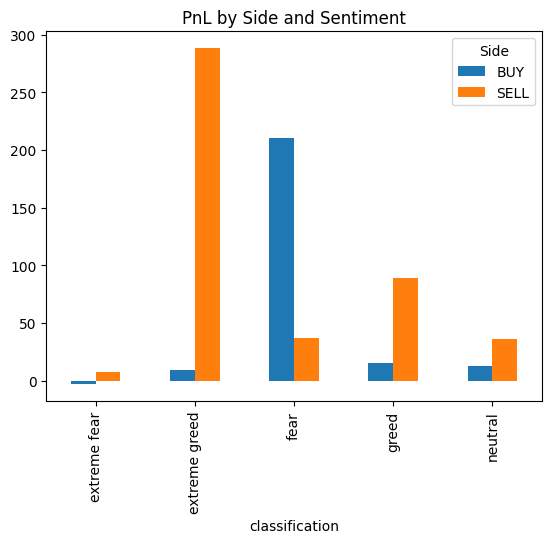

In [14]:
df.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack().plot(
    kind='bar',
    title='PnL by Side and Sentiment'
)
plt.show()

SELL trades outperform BUY trades in most sentiment conditions, especially during extreme greed.

Accuracy: 0.9401923881221247
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4087
           1       0.94      0.92      0.93      3086

    accuracy                           0.94      7173
   macro avg       0.94      0.94      0.94      7173
weighted avg       0.94      0.94      0.94      7173


Top Feature Importances:
                        feature  importance
2               Execution Price    0.536031
1                      Size USD    0.208181
0                         value    0.155107
3                     Side_SELL    0.077735
5           classification_fear    0.007775
4  classification_extreme greed    0.006850
6          classification_greed    0.004840
7        classification_neutral    0.003481


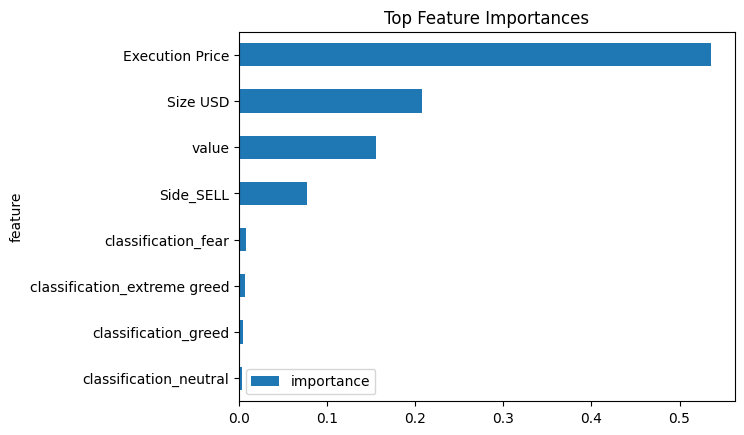

In [15]:
from src.feature_engineering import finalize_features
from src.model import run_model

X, y = finalize_features(df)
run_model(X, y)

A RandomForest model is trained to predict whether a trade is profitable based on sentiment and trade features.

## Key Insights

1. Profitability increases as sentiment moves from Fear to Greed.
2. Extreme Greed conditions yield the highest returns but also higher risk.
3. SELL trades outperform BUY trades across most sentiment regimes.
4. Execution Price, Trade Size, and Sentiment Value are the most important predictors.
5. Sentiment value is more informative than categorical labels.

## Limitations

- Significant data loss due to timestamp inconsistencies
- Model performance may be influenced by data imbalance
- Results may not generalize to all market conditions